In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [4]:
df = pd.read_csv(r"C:\Users\Prashastini N\Desktop\nassau-candy-profitability-analysis\data\cleaned_data.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Time
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,851
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,646
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,646
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,646
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-05-07,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,736


In [5]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost,Shipping Time
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087,1344.239356
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647,294.675072
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000,491.000000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000,1194.000000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000,1276.000000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000,1638.000000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000,1965.000000


The dataset contains 10,194 order records with an average sales value of about $13.9 per order and an average profit of $9.17.  
Most transactions involve small order sizes (around 3–4 units), indicating a high-volume, low-value sales model typical for confectionery distribution.

In [6]:
df.nunique()

Row ID            10194
Order ID           8549
Order Date          717
Ship Date          1338
Ship Mode             4
Customer ID        5044
Country/Region        2
City                542
State/Province       59
Postal Code         654
Division              3
Region                4
Product ID           15
Product Name         15
Sales                88
Units                14
Gross Profit        121
Cost                 95
Shipping Time       475
dtype: int64

The company serves a broad market with over 5,000 unique customers across 542 cities and 59 states.  
However, the product portfolio is relatively small with only 15 products across 3 divisions, suggesting strong reliance on a focused product range.

Sales by Region

In [7]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

region_sales

Region
Pacific     46301.53
Atlantic    41197.24
Interior    32037.60
Gulf        22247.26
Name: Sales, dtype: float64

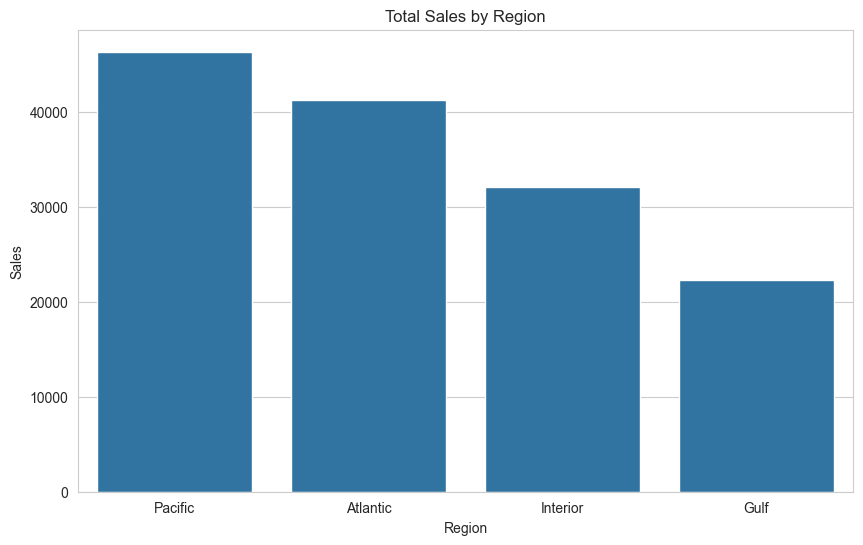

In [8]:
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.xlabel("Region")
plt.show()

The Pacific region generates the highest revenue, followed by the Atlantic and Interior regions.  
The Gulf region contributes the least sales, indicating potential opportunities for market expansion or improved distribution strategies.

Sales by Division

In [9]:
division_sales = df.groupby("Division")["Sales"].sum().sort_values(ascending=False)

division_sales

Division
Chocolate    131692.90
Other          9663.25
Sugar           427.48
Name: Sales, dtype: float64

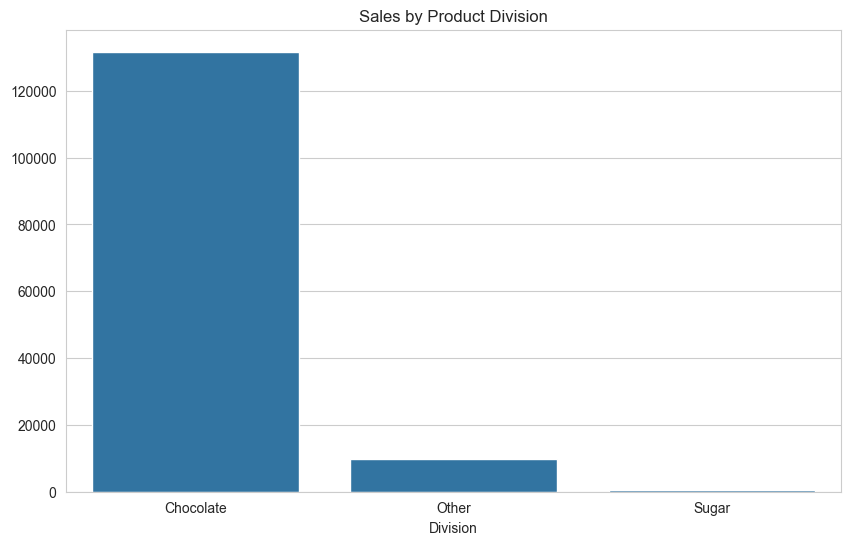

In [10]:
sns.barplot(x=division_sales.index, y=division_sales.values)
plt.title("Sales by Product Division")
plt.show()

The Chocolate division overwhelmingly dominates total sales, contributing the vast majority of revenue.  
In comparison, the Sugar and Other divisions generate very limited sales, indicating strong product concentration.

Top 10 Products by Sales

In [11]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_products

Product Name
Wonka Bar - Triple Dazzle Caramel    28485.00
Wonka Bar -Scrumdiddlyumptious       27874.80
Wonka Bar - Milk Chocolate           26867.75
Wonka Bar - Fudge Mallows            24890.40
Wonka Bar - Nutty Crunch Surprise    23574.95
Lickable Wallpaper                    7860.00
Kazookles                             1205.75
Wonka Gum                              597.50
Everlasting Gobstopper                 130.00
Fizzy Lifting Drinks                    78.75
Name: Sales, dtype: float64

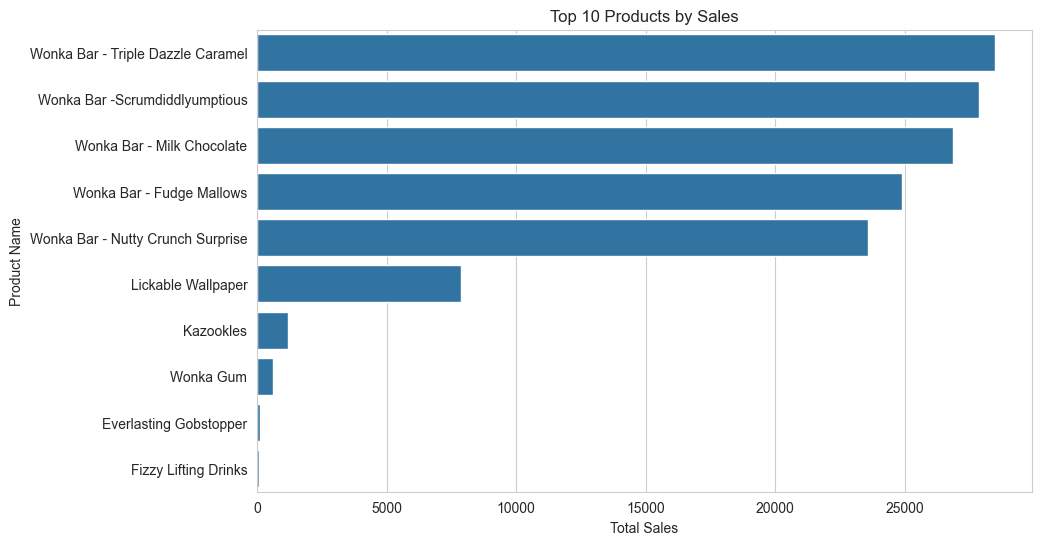

In [12]:
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.show()

The top revenue-generating products are primarily Wonka chocolate bars, with Triple Dazzle Caramel and Scrumdiddlyumptious leading sales.  
This highlights the strong demand and market dominance of the Wonka chocolate product line.

Top 10 Products by Profit

In [13]:
top_profit = df.groupby("Product Name")["Gross Profit"].sum().sort_values(ascending=False).head(10)

top_profit

Product Name
Wonka Bar -Scrumdiddlyumptious       19357.50
Wonka Bar - Triple Dazzle Caramel    18610.20
Wonka Bar - Milk Chocolate           17443.37
Wonka Bar - Nutty Crunch Surprise    16819.95
Wonka Bar - Fudge Mallows            16593.60
Lickable Wallpaper                    3930.00
Wonka Gum                              310.70
Everlasting Gobstopper                 104.00
Kazookles                               92.75
Hair Toffee                             59.50
Name: Gross Profit, dtype: float64

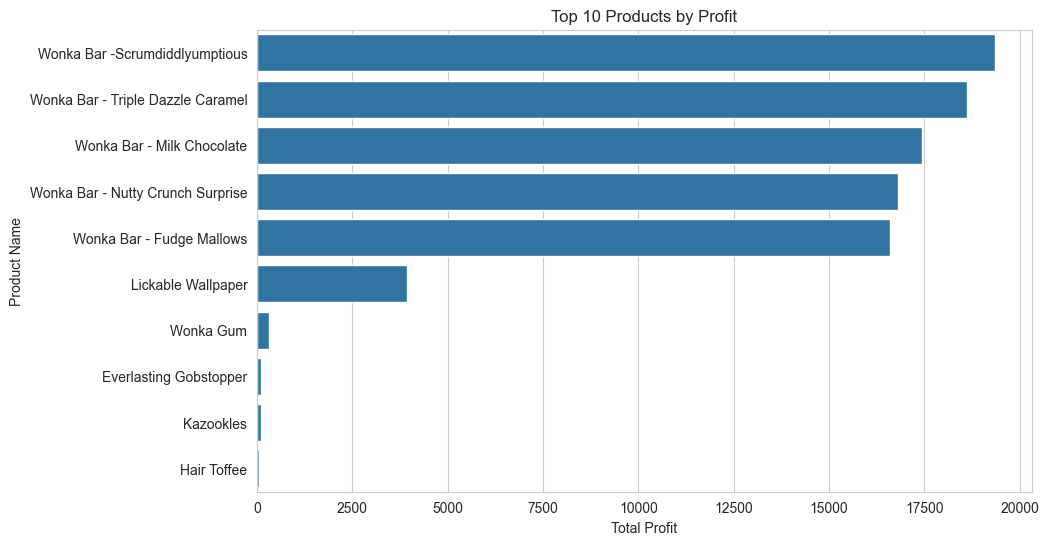

In [14]:
sns.barplot(x=top_profit.values, y=top_profit.index)
plt.title("Top 10 Products by Profit")
plt.xlabel("Total Profit")
plt.show()

Monthly Sales Trend

In [15]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Month"] = df["Order Date"].dt.to_period("M")

In [16]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales

Month
2024-01    3163.41
2024-02    2754.90
2024-03    4461.74
2024-04    3855.48
2024-05    4868.48
2024-06    3633.97
2024-07    3986.35
2024-08    4818.74
2024-09    7351.58
2024-10    4397.98
2024-11    7587.11
2024-12    7076.46
2025-01    5475.58
2025-02    5688.88
2025-03    7001.29
2025-04    5564.95
2025-05    7349.62
2025-06    5586.66
2025-07    6199.52
2025-08    7031.29
2025-09    8686.81
2025-10    7325.07
2025-11    9396.35
2025-12    8521.41
Freq: M, Name: Sales, dtype: float64

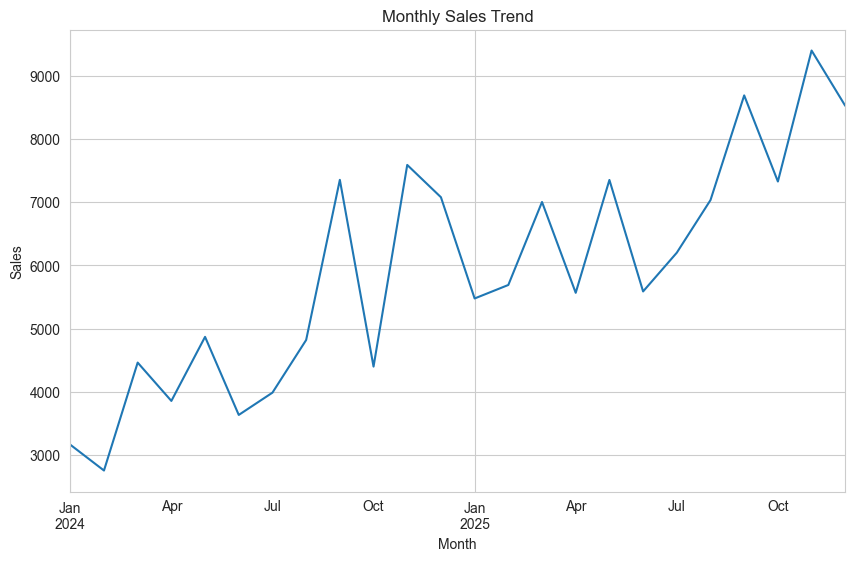

In [17]:
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

Sales show clear seasonal variation, with higher revenue observed during the later months of the year.  
The highest sales occur around September to December, likely reflecting increased demand during festive and holiday periods.

Shipping Mode Analysis

In [18]:
ship_mode = df["Ship Mode"].value_counts()

ship_mode

Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

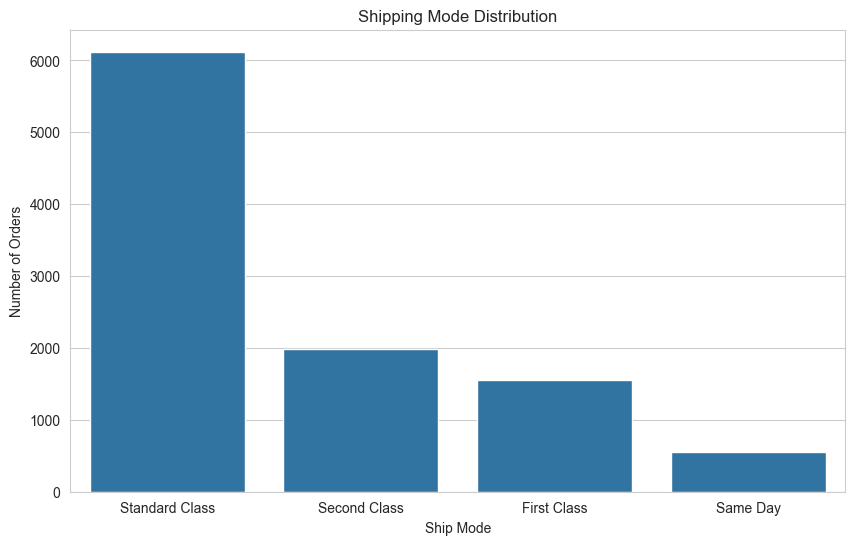

In [19]:
sns.barplot(x=ship_mode.index, y=ship_mode.values)

plt.title("Shipping Mode Distribution")
plt.ylabel("Number of Orders")
plt.show()

Standard Class shipping accounts for the majority of orders, indicating that customers generally prefer cost-efficient delivery options.  
Faster shipping modes like Same Day are used far less frequently.

Correlation Analysis

In [20]:
corr = df[["Sales","Cost","Gross Profit","Units"]].corr()

corr

,Sales,Cost,Gross Profit,Units
Sales,1.000000,0.958986,0.976404,0.729347
Cost,0.958986,1.000000,0.875144,0.563344
Gross Profit,0.976404,0.875144,1.000000,0.815820
Units,0.729347,0.563344,0.815820,1.000000


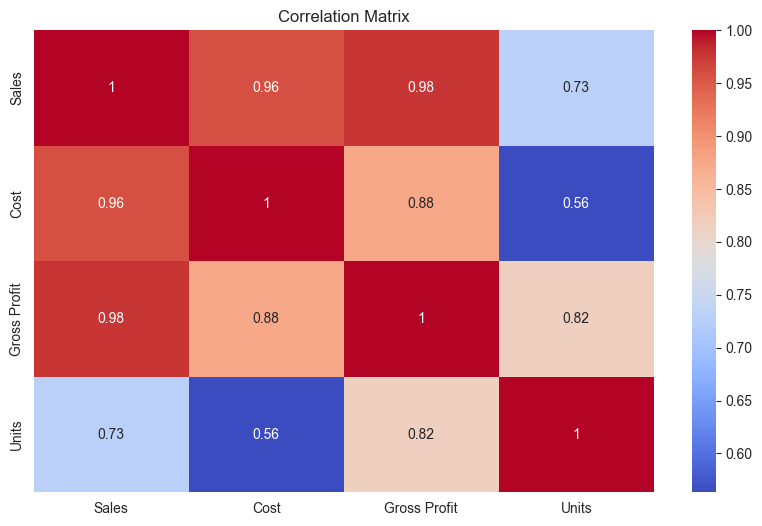

In [21]:
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

Sales and Gross Profit show a very strong positive correlation, meaning higher sales directly drive higher profitability.  
Cost also increases with sales, indicating that profitability is largely driven by sales volume.